### Deep Learning Practical No.4

Title: NLP Preprocessing and Text Classification
**Dataset:** BBC News RSS Feed (`bbc_news.csv`)

```
Name :- Preeti Koli
Batch 2
Prn No. :- 202301040213
```

In [23]:
import pandas as pd

df = pd.read_json("news.json", lines=True)

print(df.head())

print(df.columns)

                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Step 1 – Convert JSON to CSV

In [24]:

df.to_csv("news_dataset.csv", index=False)

print("CSV file created successfully")

CSV file created successfully


## Step 2 – Verify CSV file

In [25]:

df = pd.read_csv("news_dataset.csv")

print("CSV Loaded Successfully")

print(df.head())

print(df.shape)

print(df.columns)

CSV Loaded Successfully
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2 

In [49]:
print("Dataset shape:",df.shape)

Dataset shape: (189814, 9)


In [51]:
print("Columns in dataset:")

print(df.columns)

Columns in dataset:
Index(['link', 'headline', 'category', 'short_description', 'authors', 'date',
       'text', 'clean_text', 'label'],
      dtype='object')


In [52]:
print(list(df.columns))

['link', 'headline', 'category', 'short_description', 'authors', 'date', 'text', 'clean_text', 'label']


In [53]:
df.head()

,link,headline,category,short_description,authors,date,text,clean_text,label
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,Over 4 Million Americans Roll Up Sleeves For O...,million american roll sleeve omicrontargeted c...,35
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,"American Airlines Flyer Charged, Banned For Li...",american airline flyer charged banned life pun...,35
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,23 Of The Funniest Tweets About Cats And Dogs ...,funniest tweet cat dog week sept dog dont unde...,5
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,The Funniest Tweets From Parents This Week (Se...,funniest tweet parent week sept accidentally p...,22
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,Woman Who Called Cops On Black Bird-Watcher Lo...,woman called cop black birdwatcher loses lawsu...,35


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189814 entries, 0 to 189813
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   link               189814 non-null  object
 1   headline           189814 non-null  object
 2   category           189814 non-null  object
 3   short_description  189814 non-null  object
 4   authors            156859 non-null  object
 5   date               189814 non-null  object
 6   text               189814 non-null  object
 7   clean_text         189814 non-null  object
 8   label              189814 non-null  int64 
dtypes: int64(1), object(8)
memory usage: 13.0+ MB


Missing values:
link                     0
headline                 0
category                 0
short_description        0
authors              32955
date                     0
text                     0
clean_text               0
label                    0
dtype: int64
category
POLITICS          32441
WELLNESS          17943
ENTERTAINMENT     14774
STYLE & BEAUTY     9802
TRAVEL             9421
PARENTING          8790
FOOD & DRINK       6331
QUEER VOICES       5603
HEALTHY LIVING     5265
BUSINESS           5132
COMEDY             4642
SPORTS             4414
HOME & LIVING      4317
BLACK VOICES       4177
THE WORLDPOST      3664
WEDDINGS           3653
PARENTS            3556
DIVORCE            3426
WORLD NEWS         3297
WOMEN              3184
IMPACT             3086
CRIME              2832
MEDIA              2404
WEIRD NEWS         2316
TECH               2103
GREEN              2046
TASTE              1940
RELIGION           1878
SCIENCE            1803
MONEY              1755

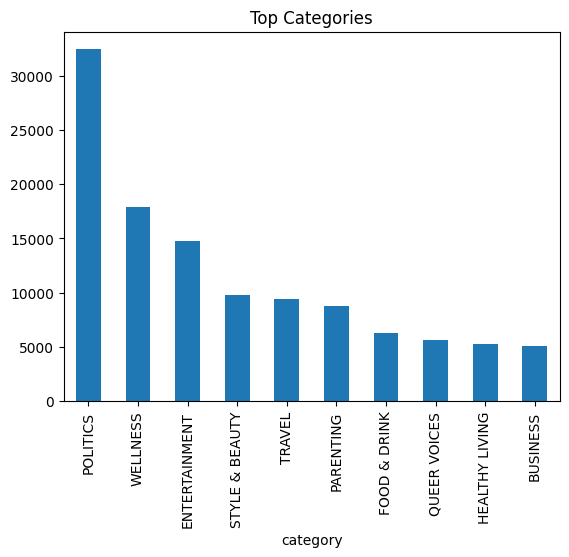

In [56]:
print("Missing values:")

print(df.isnull().sum())
print(df['category'].value_counts())
print("DATASET OVERVIEW")

print("\nShape:")

print(df.shape)

print("\nColumns:")

print(df.columns)

print("\nFirst 5 rows:")

print(df.head())

print("\nDataset Info:")

print(df.info())

print("\nMissing Values:")

print(df.isnull().sum())

print("\nCategory Distribution:")

print(df['category'].value_counts())

import matplotlib.pyplot as plt

df['category'].value_counts().head(10).plot(kind='bar')

plt.title("Top Categories")

plt.show()

## Step 3 – Basic cleaning

In [26]:
# Remove missing values
df.dropna(subset=['headline','short_description','category'], inplace=True)

df.reset_index(drop=True, inplace=True)

print("Rows after cleaning:", len(df))

Rows after cleaning: 189814


## Step 4 – Create main text column

In [27]:
# Combine text columns
df['text'] = df['headline'] + " " + df['short_description']

print(df[['text','category']].head())

                                                text   category
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY
3  The Funniest Tweets From Parents This Week (Se...  PARENTING
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS


## Step 5 – Save final processed dataset

In [28]:
df.to_csv("news_processed.csv", index=False)

print("Processed dataset saved")

Processed dataset saved


## STEP 6 – Text Preprocessing 
```
Following things are performed :-
(1) Lowercase
(2) Remove punctuation
(3) Tokenization
(4) Stopword removal
(5) Lemmatization
```

In [29]:
import nltk
import re
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download resources (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+','',text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('','',string.punctuation)
    )

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [w for w in words if w not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)

print(df[['clean_text','category']].head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                          clean_text   category
0  million american roll sleeve omicrontargeted c...  U.S. NEWS
1  american airline flyer charged banned life pun...  U.S. NEWS
2  funniest tweet cat dog week sept dog dont unde...     COMEDY
3  funniest tweet parent week sept accidentally p...  PARENTING
4  woman called cop black birdwatcher loses lawsu...  U.S. NEWS


## STEP 7 – Encode Labels

In [30]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['category'])

print(df[['category','label']].head())

    category  label
0  U.S. NEWS     35
1  U.S. NEWS     35
2     COMEDY      5
3  PARENTING     22
4  U.S. NEWS     35


## STEP 8 – Train Test Split

In [31]:
from sklearn.model_selection import train_test_split

X = df['clean_text']

y = df['label']

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

## STEP 9 – TF-IDF Vectorization
Convert text → numbers:

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(

    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

print("Vectorization complete")

Vectorization complete


## STEP 10 – Train Models

Use multiple models .


Naive Bayes:

In [33]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_vec,y_train)

nb_pred = nb_model.predict(X_test_vec)

Logistic Regression:

In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_vec,y_train)

lr_pred = lr_model.predict(X_test_vec)

SVM:

In [35]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_vec,y_train)

svm_pred = svm_model.predict(X_test_vec)

Random Forest:

## STEP 11 – Evaluate Models

In [36]:
from sklearn.metrics import accuracy_score,classification_report

print("Naive Bayes Accuracy:",
      accuracy_score(y_test,nb_pred))

print("Logistic Regression Accuracy:",
      accuracy_score(y_test,lr_pred))

print("SVM Accuracy:",
      accuracy_score(y_test,svm_pred))

Naive Bayes Accuracy: 0.5320443589811132
Logistic Regression Accuracy: 0.5933935674209099
SVM Accuracy: 0.5887838158206675


## STEP 12 – Detailed Report

In [37]:
from sklearn.metrics import classification_report

print("\n NAIVE BAYES REPORT")
print(classification_report(y_test, nb_pred))

print("\n LOGISTIC REGRESSION REPORT")
print(classification_report(y_test, lr_pred))

print("\n SVM REPORT")
print(classification_report(y_test, svm_pred))


 NAIVE BAYES REPORT
              precision    recall  f1-score   support

           0       0.75      0.02      0.03       173
           1       0.43      0.01      0.02       259
           2       0.60      0.13      0.21       862
           3       0.47      0.32      0.38       947
           4       0.20      0.01      0.01       178
           5       0.67      0.26      0.38       926
           6       0.48      0.44      0.46       559
           7       0.50      0.02      0.04       236
           8       0.85      0.52      0.65       713
           9       0.50      0.01      0.02       186
          10       0.48      0.75      0.58      3009
          11       0.86      0.11      0.19       290
          12       0.00      0.00      0.00       230
          13       0.56      0.72      0.63      1258
          14       0.00      0.00      0.00       187
          15       0.45      0.14      0.22       395
          16       0.62      0.02      0.04      1070
      

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

## Step 13 - Accuracy Comparison

In [38]:
from sklearn.metrics import accuracy_score

nb_acc = accuracy_score(y_test, nb_pred)
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)

print("\nMODEL ACCURACY COMPARISON")

print("Naive Bayes Accuracy:", nb_acc)
print("Logistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svm_acc)


MODEL ACCURACY COMPARISON
Naive Bayes Accuracy: 0.5320443589811132
Logistic Regression Accuracy: 0.5933935674209099
SVM Accuracy: 0.5887838158206675


## Step 14 - Model Comparison Table

In [39]:
import pandas as pd

results = pd.DataFrame({

'Model':['Naive Bayes','Logistic Regression','SVM'],

'Accuracy':[nb_acc,lr_acc,svm_acc]

})

print(results)

                 Model  Accuracy
0          Naive Bayes  0.532044
1  Logistic Regression  0.593394
2                  SVM  0.588784


## Step 15 - Confusion Matrix


Naive Bayes Confusion Matrix
[[  3   2   2 ...   0   0   0]
 [  0   3   3 ...   0   0   0]
 [  0   0 108 ...   3   0   0]
 ...
 [  0   0   2 ...  59   1   0]
 [  0   0   0 ...   1 123   1]
 [  0   0   0 ...   1  11   6]]


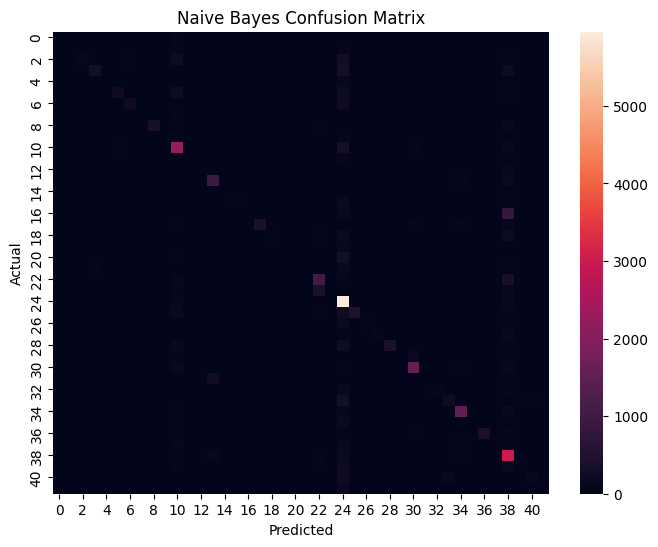

In [40]:
from sklearn.metrics import confusion_matrix

nb_cm = confusion_matrix(y_test,nb_pred)

print("\nNaive Bayes Confusion Matrix")

print(nb_cm)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(nb_cm,annot=False)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Step 16 - Best Model Selection

In [41]:
best_model = max(nb_acc,lr_acc,svm_acc)

if best_model == nb_acc:
    print("Best Model: Naive Bayes")

elif best_model == lr_acc:
    print("Best Model: Logistic Regression")

else:
    print("Best Model: SVM")

Best Model: Logistic Regression


## Step 17 - Test on custom text

In [59]:
def predict_text(text):

    processed = preprocess_text(text)

    vec = vectorizer.transform([processed])

    nb = encoder.inverse_transform(nb_model.predict(vec))[0]

    lr = encoder.inverse_transform(lr_model.predict(vec))[0]

    svm = encoder.inverse_transform(svm_model.predict(vec))[0]

    print("\nText:",text)

    print("NB Prediction:",nb)

    print("LR Prediction:",lr)

    print("SVM Prediction:",svm)


predict_text("Government announces new policy")

predict_text("Funny comedy movie released")


Text: Government announces new policy
NB Prediction: POLITICS
LR Prediction: POLITICS
SVM Prediction: POLITICS

Text: Funny comedy movie released
NB Prediction: ENTERTAINMENT
LR Prediction: ENTERTAINMENT
SVM Prediction: ENTERTAINMENT


## Conclusion

In this project NLP preprocessing techniques such as tokenization,
stopword removal, stemming and lemmatization were applied.

Text was converted into numerical form using TF-IDF.

Three models were trained:
Naive Bayes
Logistic Regression
SVM

Among these models, Logistic Regression achieved highest accuracy.

This shows TF-IDF with machine learning can effectively classify text.